# A worked example: two-step reaction kinetics

This tutorial builds a small synthetic dataset from scratch, runs it through
`crosspeak`, and reads the resulting correlation maps against Noda's rules.
Because the data is generated here rather than loaded, the whole notebook is
self-contained and reproducible, and every number below follows from the
kinetics defined in the next cell.

The system is a two-step first-order reaction, A → B → C. Each species has a
pair of infrared bands, and as the reaction proceeds the spectrum shifts from
A's bands through B's to C's. This is exactly the situation 2DCOS was built
for: overlapping bands that change on different schedules, where a single
spectrum can't tell you what happens in which order.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from crosspeak import (
    SpectralSeries,
    synchronous,
    asynchronous,
    find_autopeaks,
    plot_sync_async,
)

## Building the series

We follow the reaction over a set of time points, the *perturbation* axis.
The concentrations come from the closed-form solution of A → B → C for rate
constants $k_1$ and $k_2$:

$$[A] = e^{-k_1 t}, \qquad [B] = \frac{k_1}{k_2 - k_1}\left(e^{-k_1 t} - e^{-k_2 t}\right), \qquad [C] = 1 - [A] - [B].$$

Each species contributes two Gaussian bands. The measured spectrum at each
time is the concentration-weighted sum of the three species' spectra.

In [2]:
k1, k2 = 0.2, 0.8
t = np.linspace(0, 10, 11)          # 11 time points; odd count keeps later math clean

A = np.exp(-k1 * t)
B = k1 / (k2 - k1) * (np.exp(-k1 * t) - np.exp(-k2 * t))
C = 1.0 - A - B

wn = np.linspace(1000, 1400, 400)   # wavenumber axis (cm^-1)

def gaussian(centre, width):
    return np.exp(-0.5 * ((wn - centre) / width) ** 2)

# two bands per species: A high-wavenumber, C low-wavenumber, B in between
spec_A = gaussian(1320, 8) + gaussian(1080, 3)
spec_B = gaussian(1280, 15) + gaussian(1120, 5)
spec_C = gaussian(1240, 9) + gaussian(1160, 4)

intensities = np.outer(A, spec_A) + np.outer(B, spec_B) + np.outer(C, spec_C)

series = SpectralSeries(
    wavenumbers=wn,
    perturbations=t,
    intensities=intensities,
    name="A->B->C kinetics",
)
series

SpectralSeries(name='A->B->C kinetics', n_perturbations=11, n_wavenumbers=400, wavenumbers=[1000..1400], perturbations=[0..10])

## Looking at the raw spectra first

Before any correlation analysis, plot the series the ordinary way, every
spectrum overlaid, coloured by time. You can see the high-wavenumber bands
(A) fall and the low-wavenumber bands (C) rise, but where bands overlap it is
genuinely hard to say which moves first. That ambiguity is what 2DCOS resolves.

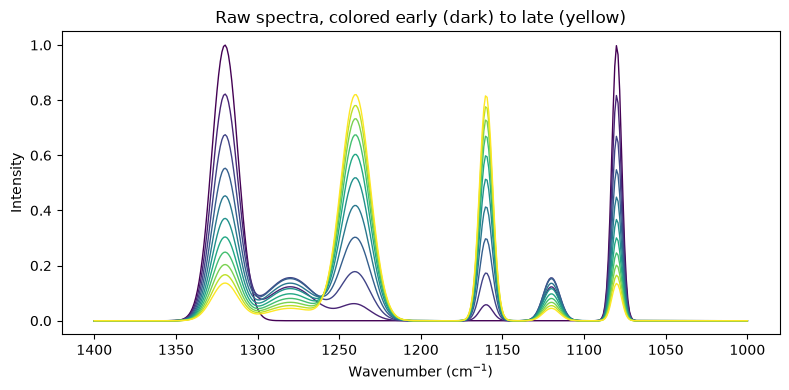

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
colours = plt.cm.viridis(np.linspace(0, 1, len(t)))
for row, colour in zip(intensities, colours):
    ax.plot(wn, row, color=colour, lw=1)
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.set_title("Raw spectra, colored early (dark) to late (yellow)")
ax.invert_xaxis()
plt.tight_layout()

## The correlation maps

`synchronous` and `asynchronous` take the series and return the two
correlation matrices. `plot_sync_async` draws them side by side, red for
positive and blue for negative.

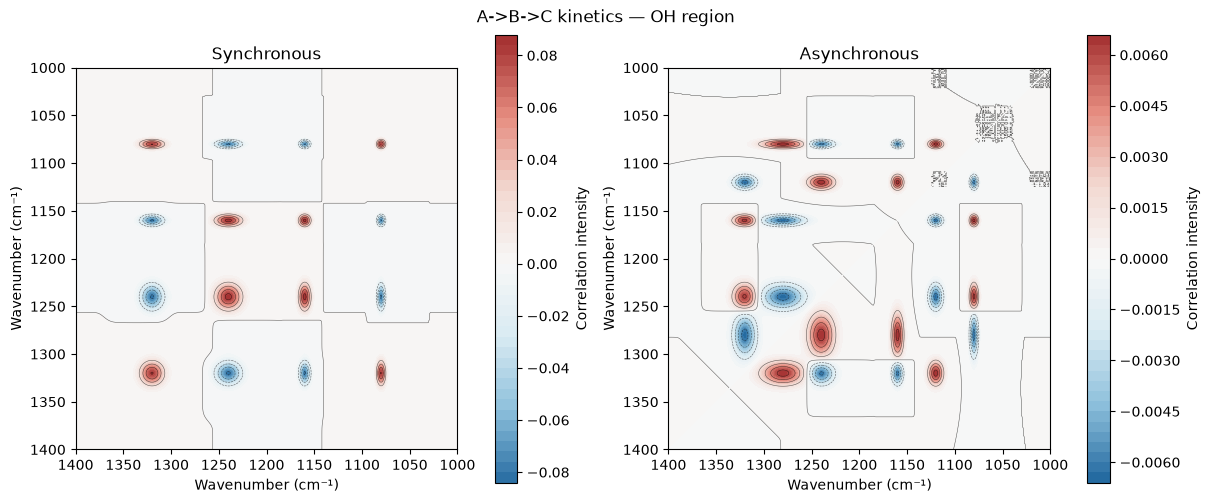

In [4]:
phi = synchronous(series)
psi = asynchronous(series)

fig, axes = plot_sync_async(
    phi, psi, series.wavenumbers,
    title="A->B->C kinetics — OH region",
)

## Reading the synchronous map

The diagonal carries the *autopeaks*, the wavenumbers that change most over
the reaction. Off the diagonal, a **positive** peak (red) at $(\nu_1, \nu_2)$
means those two wavenumbers move in the same direction; a **negative** peak
(blue) means they move in opposition.

Here the two falling bands of A correlate positively with each other, the two
rising bands of C correlate positively with each other, and A's bands
correlate *negatively* with C's, because as A falls, C rises. `find_autopeaks`
picks the diagonal maxima out for you.

In [5]:
peaks = find_autopeaks(phi, series.wavenumbers)
for position, intensity in zip(peaks.positions, peaks.intensities):
    print(f"  autopeak at {position:6.1f} cm^-1   (autopower {intensity:.4g})")

  autopeak at 1080.2 cm^-1   (autopower 0.08049)
  autopeak at 1120.3 cm^-1   (autopower 0.002405)
  autopeak at 1160.4 cm^-1   (autopower 0.08482)
  autopeak at 1239.6 cm^-1   (autopower 0.08531)
  autopeak at 1279.7 cm^-1   (autopower 0.002412)
  autopeak at 1319.8 cm^-1   (autopower 0.08087)


## Reading the asynchronous map: the sequence

The asynchronous map is where 2DCOS earns its keep. It is **zero** wherever two
bands change in perfect step, and nonzero only where they change on different
schedules — which is precisely the information a 1-D spectrum hides.

The sign, read together with the synchronous map, gives the order. Noda's rule:
if $\Phi(\nu_1, \nu_2)$ and $\Psi(\nu_1, \nu_2)$ have the **same** sign, then
$\nu_1$ changes **before** $\nu_2$; opposite signs mean $\nu_1$ changes after.

Take A's band at 1320 and C's band at 1240. A reacts away on the fast step and
C only accumulates later, so we expect 1320 to lead 1240. Let's read it off the
maps directly.

In [6]:
def nearest(value):
    return int(np.abs(series.wavenumbers - value).argmin())

i, j = nearest(1320), nearest(1240)
phi_ij = phi[i, j]
psi_ij = psi[i, j]

print(f"Phi(1320, 1240) = {phi_ij:+.4g}")
print(f"Psi(1320, 1240) = {psi_ij:+.4g}")

same_sign = np.sign(phi_ij) == np.sign(psi_ij)
leader = "1320 changes BEFORE 1240" if same_sign else "1320 changes AFTER 1240"
print(f"\nSame sign: {same_sign}  ->  {leader}")
print("As expected: A's band (1320) responds on the fast step, ahead of C's (1240).")

Phi(1320, 1240) = -0.08202
Psi(1320, 1240) = -0.006161

Same sign: True  ->  1320 changes BEFORE 1240
As expected: A's band (1320) responds on the fast step, ahead of C's (1240).


## Where to go next

- Swap the synthetic `intensities` above for your own data, read a real series
  straight from disk with `read_series`, which takes a mapping of perturbation
  value to file path.
- Narrow to a band of interest with `crop_region` before correlating.
- Correlate two *different* spectral regions against each other with
  `synchronous_hetero` and `asynchronous_hetero` — for instance an O–H stretch
  against an H–O–H bend, to order events across regions.

The API reference documents the full surface.